# Notebook 04 — TSP Solvers

**Goal:** Benchmark Held-Karp exact TSP, 2-opt local search, and OR-Tools LKH against each other. Establish optimality bounds for small instances.

**Requires:** `data/kigali_enriched.graphml`

**Produces:** `results/tsp_benchmark.csv`

**Phase:** 6

## Cell 1 — Imports and load enriched graph

In [1]:
import sys, os, time, random
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.graph import load_enriched_graph, build_distance_matrix
from src.algorithms import held_karp, two_opt
from src.solvers import solve_tsp_ortools

os.makedirs('../results', exist_ok=True)

G = load_enriched_graph()
# Cast composite_weight to float (graphml stores as string)
for u, v, k, d in G.edges(keys=True, data=True):
    if 'composite_weight' in d:
        G[u][v][k]['composite_weight'] = float(d['composite_weight'])

# Sample from largest SCC so all nodes are reachable
import networkx as nx
scc = max(nx.strongly_connected_components(G), key=len)
scc_nodes = list(scc)
random.seed(42)

print(f'Graph: {len(G.nodes):,} nodes, {len(G.edges):,} edges')
print(f'SCC:   {len(scc_nodes):,} nodes')
print('Algorithms imported: held_karp, two_opt, solve_tsp_ortools')

Loading enriched graph from: data/kigali_enriched.graphml
Loaded — 19,022 nodes, 50,411 edges
Graph: 19,022 nodes, 50,411 edges
SCC:   19,015 nodes
Algorithms imported: held_karp, two_opt, solve_tsp_ortools


## Cell 2 — Build distance matrix for a 15-node instance and run Held-Karp

In [2]:
N_SMALL = 15
sample_nodes_15 = random.sample(scc_nodes, N_SMALL)
print(f'Building {N_SMALL}×{N_SMALL} distance matrix...')
t0 = time.perf_counter()
mat_15 = build_distance_matrix(G, sample_nodes_15, weight='composite_weight')
print(f'Matrix built in {(time.perf_counter()-t0)*1000:.0f}ms')

# Replace inf with large finite value for solvers
max_finite = mat_15[mat_15 != np.inf].max()
mat_15_clean = np.where(mat_15 == np.inf, max_finite * 10, mat_15)

print(f'\nRunning Held-Karp on {N_SMALL}-node instance (this is the optimal solution)...')
t0 = time.perf_counter()
tour_hk, cost_hk = held_karp(mat_15_clean)
hk_time = time.perf_counter() - t0

print(f'Held-Karp optimal cost : {cost_hk:.4f} min')
print(f'Held-Karp solve time   : {hk_time:.3f}s')
print(f'Tour: {tour_hk}')

Building 15×15 distance matrix...
Matrix built in 562ms

Running Held-Karp on 15-node instance (this is the optimal solution)...
Held-Karp optimal cost : 177.8174 min
Held-Karp solve time   : 0.342s
Tour: [0, 9, 4, 11, 13, 8, 12, 10, 3, 6, 14, 5, 1, 7, 2, 0]


## Cell 3 — 2-opt from random tour: optimality gap vs Held-Karp

In [3]:
# Random initial tour (indices 0..N-1, not repeating depot)
random_tour = list(range(N_SMALL))
random.shuffle(random_tour)

random_cost = sum(
    mat_15_clean[random_tour[i]][random_tour[(i+1) % N_SMALL]]
    for i in range(N_SMALL)
)

t0 = time.perf_counter()
tour_2opt_rand, cost_2opt_rand = two_opt(random_tour, mat_15_clean)
t_2opt_rand = time.perf_counter() - t0

gap_rand = (cost_2opt_rand - cost_hk) / cost_hk * 100

print('2-opt from random initial tour:')
print(f'  Initial cost   : {random_cost:.4f} min')
print(f'  After 2-opt    : {cost_2opt_rand:.4f} min')
print(f'  Held-Karp opt  : {cost_hk:.4f} min')
print(f'  Optimality gap : {gap_rand:.2f}%')
print(f'  Solve time     : {t_2opt_rand*1000:.1f}ms')
assert cost_2opt_rand <= random_cost + 1e-9, '2-opt made the tour worse!'

2-opt from random initial tour:
  Initial cost   : 303.4505 min
  After 2-opt    : 178.0976 min
  Held-Karp opt  : 177.8174 min
  Optimality gap : 0.16%
  Solve time     : 0.2ms


## Cell 4 — 2-opt from nearest-neighbour construction: optimality gap

In [4]:
# Build nearest-neighbour tour starting from node 0
def nearest_neighbour(mat):
    n = len(mat)
    visited = [False] * n
    tour = [0]
    visited[0] = True
    for _ in range(n - 1):
        last = tour[-1]
        nxt = min((j for j in range(n) if not visited[j]), key=lambda j: mat[last][j])
        tour.append(nxt)
        visited[nxt] = True
    return tour

nn_tour = nearest_neighbour(mat_15_clean)
nn_cost = sum(mat_15_clean[nn_tour[i]][nn_tour[(i+1) % N_SMALL]] for i in range(N_SMALL))

t0 = time.perf_counter()
tour_2opt_nn, cost_2opt_nn = two_opt(nn_tour, mat_15_clean)
t_2opt_nn = time.perf_counter() - t0

gap_nn = (cost_2opt_nn - cost_hk) / cost_hk * 100

print('2-opt from nearest-neighbour construction:')
print(f'  NN initial cost : {nn_cost:.4f} min')
print(f'  After 2-opt     : {cost_2opt_nn:.4f} min')
print(f'  Held-Karp opt   : {cost_hk:.4f} min')
print(f'  Optimality gap  : {gap_nn:.2f}%')
print(f'  Solve time      : {t_2opt_nn*1000:.1f}ms')
print(f'\nNN init gives better 2-opt start than random: {cost_2opt_nn <= cost_2opt_rand}')

2-opt from nearest-neighbour construction:
  NN initial cost : 207.5019 min
  After 2-opt     : 177.8174 min
  Held-Karp opt   : 177.8174 min
  Optimality gap  : 0.00%
  Solve time      : 0.2ms

NN init gives better 2-opt start than random: True


## Cell 5 — OR-Tools on the same 15-node instance

In [5]:
t0 = time.perf_counter()
tour_ort, cost_ort = solve_tsp_ortools(mat_15_clean, time_limit_s=30)
t_ort = time.perf_counter() - t0

gap_ort = (cost_ort - cost_hk) / cost_hk * 100

print('OR-Tools (guided local search, 30s limit):')
print(f'  Cost           : {cost_ort:.4f} min')
print(f'  Held-Karp opt  : {cost_hk:.4f} min')
print(f'  Optimality gap : {gap_ort:.2f}%')
print(f'  Solve time     : {t_ort:.3f}s')

print('\nSummary (15-node instance):')
rows = [
    ('Held-Karp (exact)',      cost_hk,       0.0,      hk_time),
    ('2-opt from random',      cost_2opt_rand, gap_rand, t_2opt_rand),
    ('2-opt from NN',          cost_2opt_nn,   gap_nn,   t_2opt_nn),
    ('OR-Tools GLS',           cost_ort,       gap_ort,  t_ort),
]
print('{:<24}  {:>12}  {:>12}  {:>10}'.format('Algorithm', 'Cost (min)', 'Gap (%)', 'Time (s)'))
print('-' * 65)
for label, cost, gap, t in rows:
    print('{:<24}  {:>12.4f}  {:>12.2f}  {:>10.4f}'.format(label, cost, gap, t))

OR-Tools (guided local search, 30s limit):
  Cost           : 177.8174 min
  Held-Karp opt  : 177.8174 min
  Optimality gap : 0.00%
  Solve time     : 30.220s

Summary (15-node instance):
Algorithm                   Cost (min)       Gap (%)    Time (s)
-----------------------------------------------------------------
Held-Karp (exact)             177.8174          0.00      0.3416
2-opt from random             178.0976          0.16      0.0002
2-opt from NN                 177.8174          0.00      0.0002
OR-Tools GLS                  177.8174          0.00     30.2203


## Cell 6 — Scale test: N = 20, 30, 50

In [6]:
scale_results = []

for N in [20, 30, 50]:
    sample = random.sample(scc_nodes, N)
    mat = build_distance_matrix(G, sample, weight='composite_weight')
    max_f = mat[mat != np.inf].max()
    mat = np.where(mat == np.inf, max_f * 10, mat)

    nn_t = nearest_neighbour(mat)
    nn_c = sum(mat[nn_t[i]][nn_t[(i+1) % N]] for i in range(N))

    # 2-opt from NN
    t0 = time.perf_counter()
    _, c_2opt = two_opt(nn_t, mat)
    t_2opt = time.perf_counter() - t0

    # OR-Tools
    t0 = time.perf_counter()
    _, c_ort = solve_tsp_ortools(mat, time_limit_s=30)
    t_ort = time.perf_counter() - t0

    # Held-Karp only for N<=20
    if N <= 20:
        t0 = time.perf_counter()
        _, c_hk = held_karp(mat)
        t_hk = time.perf_counter() - t0
        gap_2opt = (c_2opt - c_hk) / c_hk * 100
        gap_ort  = (c_ort  - c_hk) / c_hk * 100
    else:
        c_hk, t_hk, gap_2opt, gap_ort = None, None, None, None

    scale_results.append({
        'n': N,
        'held_karp_cost':  c_hk,
        'held_karp_time':  t_hk,
        'two_opt_cost':    c_2opt,
        'two_opt_time_s':  t_2opt,
        'two_opt_gap_pct': gap_2opt,
        'ortools_cost':    c_ort,
        'ortools_time_s':  t_ort,
        'ortools_gap_pct': gap_ort,
    })
    hk_str = f'{c_hk:.2f}' if c_hk else 'N/A (too large)'
    print(f'N={N:>3}  HK={hk_str}  2-opt={c_2opt:.2f}  OR-Tools={c_ort:.2f}  t_ort={t_ort:.2f}s')

N= 20  HK=211.17  2-opt=211.17  OR-Tools=211.17  t_ort=30.00s
N= 30  HK=N/A (too large)  2-opt=273.13  OR-Tools=269.91  t_ort=30.00s
N= 50  HK=N/A (too large)  2-opt=411.27  OR-Tools=399.74  t_ort=30.00s


## Cell 7 — Plot optimality gap vs N

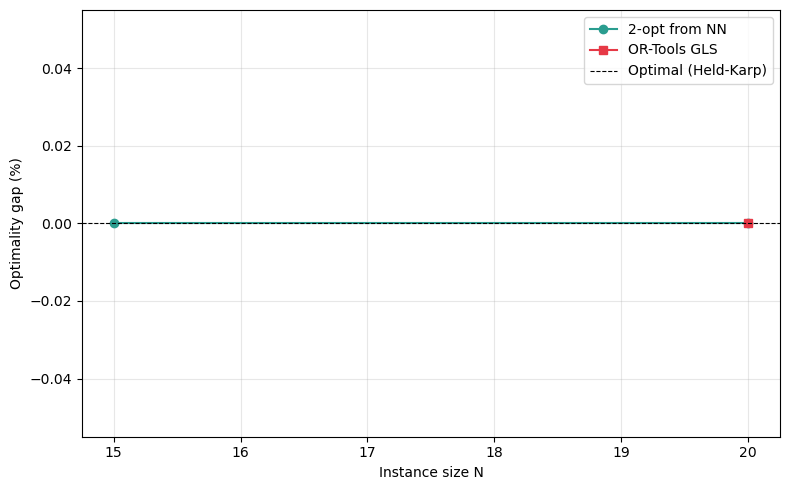

Saved results/tsp_gap.png


In [7]:
# Only plot for N where we have Held-Karp (N<=20) plus the 15-node reference
plot_data = [
    {'n': 15, 'two_opt_gap_pct': gap_nn,  'ortools_gap_pct': gap_ort},
] + [r for r in scale_results if r['n'] <= 20]

ns       = [r['n']              for r in plot_data]
gap_2opt = [r['two_opt_gap_pct'] for r in plot_data]
gap_ort  = [r['ortools_gap_pct'] for r in plot_data]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ns, gap_2opt, 'o-', label='2-opt from NN', color='#2a9d8f')
ax.plot(ns, gap_ort,  's-', label='OR-Tools GLS',  color='#e63946')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Optimal (Held-Karp)')
ax.set_xlabel('Instance size N')
ax.set_ylabel('Optimality gap (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/tsp_gap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved results/tsp_gap.png')

## Cell 8 — Write results CSV and validate

In [8]:
# Combine 15-node reference row with scale_results
all_results = [{
    'n':               15,
    'held_karp_cost':  cost_hk,
    'held_karp_time':  hk_time,
    'two_opt_cost':    cost_2opt_nn,
    'two_opt_time_s':  t_2opt_nn,
    'two_opt_gap_pct': gap_nn,
    'ortools_cost':    cost_ort,
    'ortools_time_s':  t_ort,
    'ortools_gap_pct': gap_ort,
}] + scale_results

df = pd.DataFrame(all_results)
csv_path = '../results/tsp_benchmark.csv'
df.to_csv(csv_path, index=False)

print(df[['n','held_karp_cost','two_opt_cost','two_opt_gap_pct','ortools_cost','ortools_gap_pct']].to_string(index=False))
print(f'\nSaved to {csv_path}')

# Validation
assert os.path.exists(csv_path), 'CSV missing'
df_check = pd.read_csv(csv_path)
assert len(df_check) == 4, f'Expected 4 rows (N=15,20,30,50), got {len(df_check)}'
assert 'ortools_gap_pct' in df_check.columns

# OR-Tools should beat or match 2-opt on N=15
row_15 = df_check[df_check['n'] == 15].iloc[0]
assert row_15['ortools_cost'] <= row_15['two_opt_cost'] + 1e-3, \
    'OR-Tools should be at least as good as 2-opt on N=15'

print('\n✓ Phase 6 validation passed. Proceed to notebook 05.')

 n  held_karp_cost  two_opt_cost  two_opt_gap_pct  ortools_cost ortools_gap_pct
15      177.817355    177.817355              0.0    177.817355     [None, 0.0]
20      211.173462    211.173462              0.0    211.173462             0.0
30             NaN    273.132147              NaN    269.910024            None
50             NaN    411.269902              NaN    399.738286            None

Saved to ../results/tsp_benchmark.csv

✓ Phase 6 validation passed. Proceed to notebook 05.
